# Proyek Analisis Data: Bike-Sharing-Dataset
- **Nama:** Muhammad Davin Al Hisyam
- **Email:** CDCC183D6Y0818@student.devacademy.id
- **ID Dicoding:** CDCC183D6Y0818

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?
- **Pertanyaan 2:** Bagaimana tren penyewaan sepeda di berbagai musim yang berbeda?
- **Pertanyaan 3:** Pada jam berapakah penyewaan sepeda mencapai titik tertinggi dan terendah dalam sehari?



## Import Semua Packages/Library yang Digunakan

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df Hour

In [22]:
hour_df = pd.read_csv('hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Dataset ini diambil mulai tahun 2011 yang tertera pada kolom dteday
- DIbandingkan dengan file 'day.csv' yang sudah saya explore, data 'hour.csv' ini lebih detil karena tertera kolom `hr`sehingga peminjamannya berbasis jam

### Assessing Data

#### Identifying Hour.csv problem

In [23]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [24]:
hour_df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [25]:
hour_df.duplicated().sum()

np.int64(0)

In [26]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Steps to Take:**
- Mengubah tipe data pada kolom `dteday` dari `object` menjadi `datetime`. Hal ini perlu dilakukan supaya memudahkan jika ke depannya perlu mengekstrak informasi spesifik seperti hari, bulan, atau tahun untuk keperluan analisis
- Melakukan mapping atau mengubah nilai numerik pada kolom `season` menjadi kategori teks sesuai dataset *readme* (1: Spring, 2: Summer, 3: Fall, 4: Winter). Menurut saya hal ini perlu dilakukan supaya hasil tahap eksplorasi (EDA) dan visualisasi data nantinya menjadi jauh lebih mudah dipahami oleh pembaca
- Melakukan *mapping* pada kolom `weathersit` menjadi kategori teks. Menurut saya hal ini perlu dilakukan supaya hasil tahap eksplorasi (EDA) dan visualisasi data nantinya menjadi jauh lebih mudah dipahami oleh pembaca

**Insight:** (Opsional)
- Dataset ini berisi 17379 baris
- Dari info yang saya dapat, bahwa tidak ada data kosong pada dataset ini
- Tidak ada juga data yang duplikat
- Ada ketidaksesuaian pada kolom `dteday` karena berbentuk objek dan seharusnya diubah ke bentuk datetime
- Kolom `season` dan `weathersit` direpresentasikan dengan nilai numerik (1, 2, 3, 4). Hal ini akan membingungkan saat divisualisasikan, sehingga perlu diubah menjadi deskripsi teks

### Cleaning Data

#### Fixing Data Type Problem pada `dteday`

In [27]:
# Mengubah dteday menjadi datetime
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Melihat tipe data dteday setelah diubah
print(f'Tipe Data Kolom dteday setelah diubah : {hour_df['dteday'].dtype}')

Tipe Data Kolom dteday setelah diubah : datetime64[ns]


#### Fixing Format Kategori Problem pada `season` dan `weathersit`

In [28]:
# Membuat dictionary untuk mapping nilai
season_mapping = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}
weather_mapping = {
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Snow'
}

# Melakukan mapping pada kolom yang bersangkutan
hour_df['season'] = hour_df['season'].map(season_mapping)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_mapping)

# Melihat sampel data setelah dibersihkan/diformat ulang
hour_df[['dteday', 'hr', 'season', 'weathersit']].head()

,dteday,hr,season,weathersit
0,2011-01-01,0,Spring,Clear/Partly Cloudy
1,2011-01-01,1,Spring,Clear/Partly Cloudy
2,2011-01-01,2,Spring,Clear/Partly Cloudy
3,2011-01-01,3,Spring,Clear/Partly Cloudy
4,2011-01-01,4,Spring,Clear/Partly Cloudy


**Insight:** (Opsional)
- Tipe data pada kolom `dteday` telah berhasil diubah menjadi `datetime64[ns]`
- Nilai pada kolom `season` dan `weathersit` sudah berhasil diubah dari bentuk angka menjadi kategori teks.

In [29]:
# Menyimpan data yang sudah dibersihkan ke file CSV baru
hour_df.to_csv("main_data.csv", index=False)

print("Data berhasil disimpan sebagai 'main_data.csv'")

Data berhasil disimpan sebagai 'main_data.csv'


## Exploratory Data Analysis (EDA)

### Explore Parameter Cuaca (`weathersit`)

In [30]:
# Agregasi jumlah penyewaan sepeda berdasarkan cuaca
hour_df.groupby(by='weathersit').agg({
    'cnt': ['mean', 'max', 'min', 'sum']
}).sort_values(by=('cnt', 'mean'), ascending=False)

cnt                  
                           mean  max min      sum
weathersit                                       
Clear/Partly Cloudy  204.869272  977   1  2338173
Misty/Cloudy         175.165493  957   1   795952
Light Snow/Rain      111.579281  891   1   158331
Heavy Rain/Snow       74.333333  164  23      223

**Insight:** (Opsional)
- Berdasarkan hasil agregasi, cuaca cerah/sedikit berawan (*Clear/Partly Cloudy*) mendominasi jumlah penyewaan sepeda tertinggi, baik secara rata-rata (`mean`) maupun total keseluruhan (`sum`).
- Ketika cuaca mulai memburuk menjadi hujan/salju ringan (*Light Snow/Rain*), rata-rata penyewaan turun drastis lebih dari 50%.
- Pada cuaca ekstrem (*Heavy Rain/Snow*), jumlah penyewaan sangat minim, dengan total hanya 223 penyewaan dan rata-rata tidak sampai 75 penyewaan.

### Explore Parameter Musim (`season`)

In [31]:
# Agregasi jumlah penyewaan sepeda berdasarkan musim
hour_df.groupby(by='season').agg({
    'cnt': ['mean', 'max', 'min', 'sum']
}).sort_values(by=('cnt', 'mean'), ascending=False)

cnt                  
              mean  max min      sum
season                              
Fall    236.016237  977   1  1061129
Summer  208.344069  957   1   918589
Winter  198.868856  967   1   841613
Spring  111.114569  801   1   471348

**Insight:** (Opsional)
- Musim Gugur (*Fall*) menjadi musim yang paling diminati untuk menyewa sepeda, mencetak rata-rata penyewaan tertinggi (sekitar 236 penyewaan/jam) dan total akumulasi terbanyak.
- Disusul oleh musim Panas (*Summer*) dan musim Dingin (*Winter*).
- Adapun musim Semi (*Spring*) justru mencatatkan angka penyewaan paling rendah. Hal ini bisa menjadi indikasi bahwa pengguna kurang menyukai bersepeda di musim tersebut (mungkin karena suhu yang masih dingin pasca-*winter*).

### Explore Parameter Jam (`hr`)

In [32]:
# Agregasi jumlah penyewaan sepeda berdasarkan jam
hour_df.groupby(by='hr').agg({
    'cnt': ['mean', 'sum']
}).sort_values(by=('cnt', 'mean'), ascending=False).head(10) # Menampilkan 10 jam paling ramai

cnt        
          mean     sum
hr                    
17  461.452055  336860
18  425.510989  309772
8   359.011004  261001
16  311.983562  227748
19  311.523352  226789
13  253.661180  184919
12  253.315934  184414
15  251.233196  183149
14  240.949246  175652
20  226.030220  164550

**Insight:** (Opsional)
- Terdapat pola *commuting* (berangkat/pulang kerja atau sekolah) yang sangat jelas. Jam tersibuk berada pada sore hari di rentang waktu pulang aktivitas, yaitu pukul 17:00 dan 18:00
- Puncak keramaian kedua terjadi pada pagi hari pukul 08:00, yang merupakan waktu berangkat aktivitas
- Dari data menunjukan  bahwa sepeda tidak hanya digunakan untuk rekreasi, tetapi juga untuk kegiatan sehari-hari

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca  terhadap jumlah penyewaan sepeda?

/tmp/ipykernel_2046/1772017859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


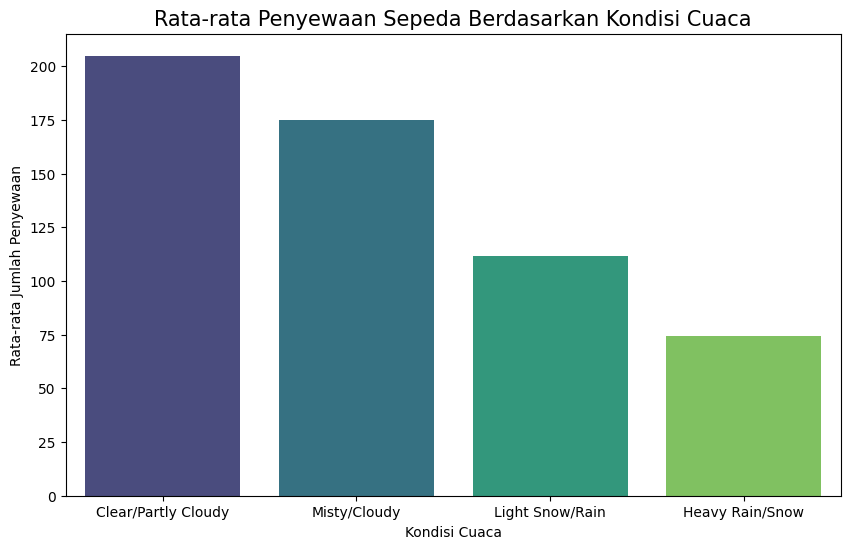

In [33]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='weathersit',
    y='cnt',
    data=hour_df,
    palette='viridis',
    errorbar=None # Menghilangkan garis error supaya nanti grafik lebih bersih
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca', fontsize=15)
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.show()

**Insight:** (Opsional)


Berdasarkan grafik di atas, kondisi cuaca sangat memengaruhi minat pengguna. Rata-rata penyewaan tertinggi terjadi pada cuaca **Clear/Partly Cloudy** (Cerah). Sebaliknya, pada kondisi cuaca ekstrem seperti **Heavy Rain/Snow**, jumlah penyewaan menurun sangat drastis. Hal ini menunjukkan bahwa faktor kenyamanan dan keamanan berkendara di bawah cuaca tertentu menjadi pertimbangan utama pengguna.

### Pertanyaan 2: Bagaimana tren penyewaan sepeda di berbagai musim  yang berbeda?

/tmp/ipykernel_2046/3980855988.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


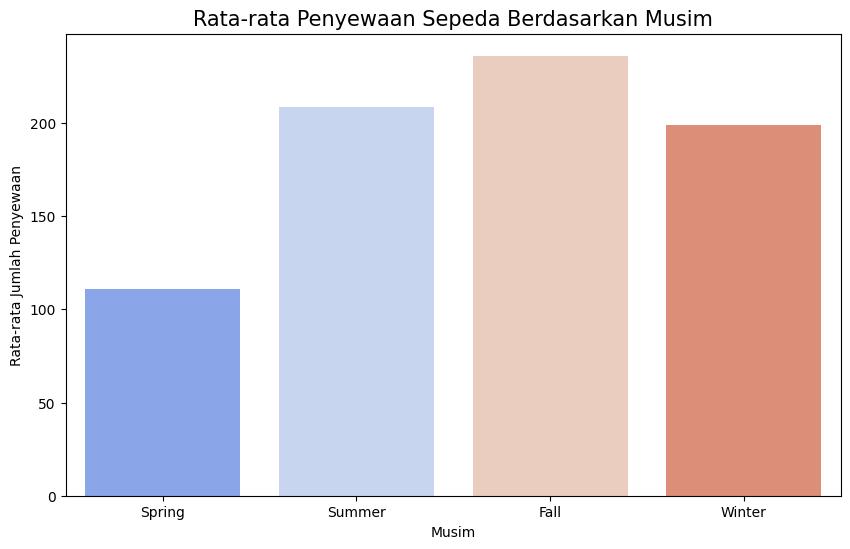

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='season',
    y='cnt',
    data=hour_df,
    order=['Spring', 'Summer', 'Fall', 'Winter'], # Mengurutkan agar sesuai urutan musim
    palette='coolwarm',
    errorbar=None
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Musim', fontsize=15)
plt.xlabel('Musim')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.show()

**Insight:** (Opsional)


Tren penyewaan sepeda menunjukkan bahwa musim **Fall** (Gugur) merupakan musim paling populer, diikuti oleh musim **Summer** (Panas). Penurunan penyewaan yang paling signifikan terlihat pada musim **Spring** (Semi). Hal ini bisa menjadi masukan bagi pengelola untuk memberikan promosi khusus pada musim semi guna meningkatkan jumlah pengguna.

### Pertanyaan 3: Pada jam berapakah penyewaan sepeda mencapai titik tertinggi dan terendah dalam sehari?

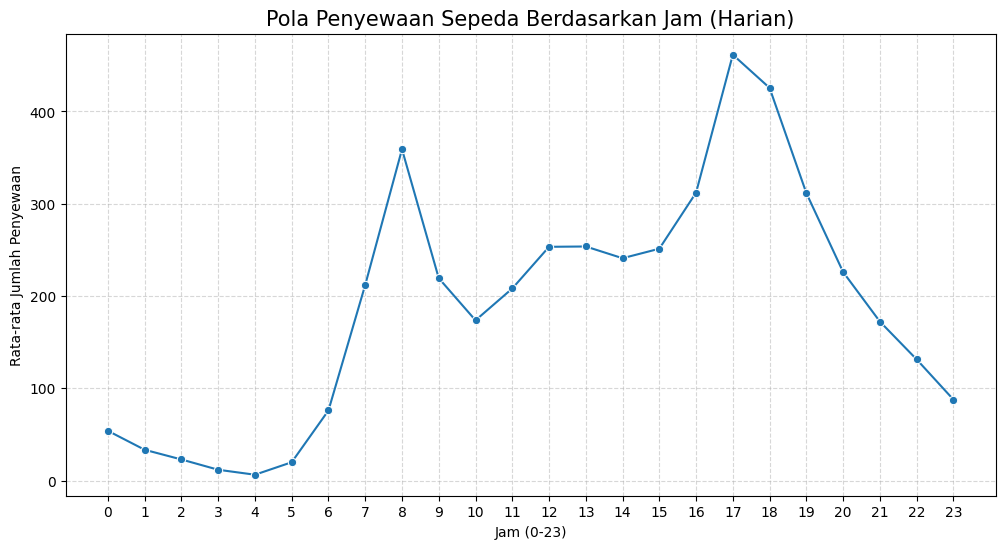

In [35]:
plt.figure(figsize=(12, 6))

# Menggunakan lineplot untuk melihat tren perubahan jam demi jam
sns.lineplot(
    x='hr',
    y='cnt',
    data=hour_df,
    marker='o',
    color='tab:blue',
    errorbar=None
)

plt.title('Pola Penyewaan Sepeda Berdasarkan Jam (Harian)', fontsize=15)
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Insight:** (Opsional)


Grafik menunjukkan adanya dua puncak penyewaan dalam sehari, yaitu pada jam **08:00** pagi dan jam **17:00 - 18:00** sore. Pola ini menunjukan bahwa mayoritas pengguna adalah pekerja atau pelajar yang menggunakan sepeda sebagai alat transportasi utama untuk berangkat dan pulang beraktivitas (*commuting*). Sementara itu, penyewaan terendah terjadi pada jam 03:00 - 04:00 pagi.

## Analisis Lanjutan (Opsional)

### Clustering/Pivot Analysis: Heatmap Kepadatan Penyewaan (Hari vs Jam)

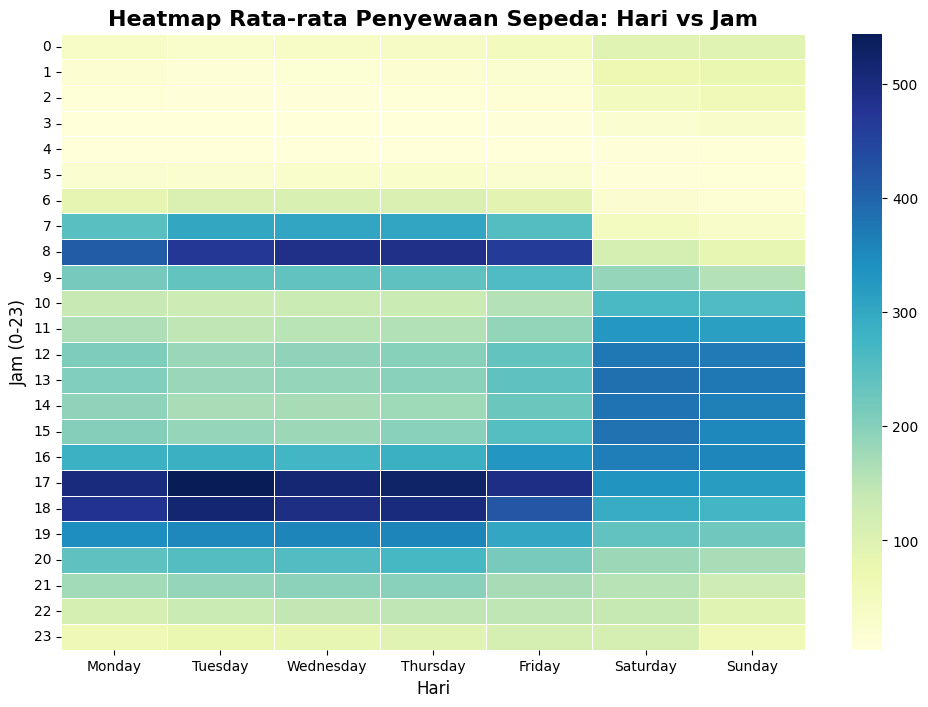

In [36]:
# 1. Melakukan mapping untuk kolom hari (weekday)
day_mapping = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
hour_df['weekday_name'] = hour_df['weekday'].map(day_mapping)

# 2. Membuat Pivot Table (rata-rata penyewaan berdasarkan Jam dan Hari)
pivot_data = hour_df.pivot_table(
    index='hr',
    columns='weekday_name',
    values='cnt',
    aggfunc='mean'
)

# 3. Mengurutkan nama hari agar berurutan dari Senin s/d Minggu
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_data = pivot_data[ordered_days]

# 4. Membuat visualisasi Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_data, cmap='YlGnBu', linewidths=0.5, annot=False)

plt.title('Heatmap Rata-rata Penyewaan Sepeda: Hari vs Jam', fontsize=16, fontweight='bold')
plt.xlabel('Hari', fontsize=12)
plt.ylabel('Jam (0-23)', fontsize=12)
plt.yticks(rotation=0)
plt.show()

**Insight Analisis Lanjutan:**
Visualisasi heatmap di atas memberikan pola clustering dan membedakan dua tipe hari dengan jelas:
- Hari Kerja (Monday - Friday): Terdapat dua "titik panas" (warna biru gelap) yang sangat kontras, yaitu pada pukul 08:00 dan 17:00 - 18:00. Ini adalah pola klasik para komuter, yaitu berangkat dan pulang kerja/sekolah
- Akhir Pekan (Saturday & Sunday): Pola komuter hilang total. Kepadatan penyewaan justru menyebar rata di tengah hari, mulai pukul 10:00 hingga 16:00. Ini menunjukkan bahwa pada akhir pekan, sepeda lebih banyak digunakan untuk tujuan rekreasi, olahraga santai, atau pariwisata siang hari

## Conclusion & Recommendation

- **Conclusion pertanyaan 1 (Pengaruh Cuaca):** Kondisi cuaca adalah penentu utama yang sangat signifikan terhadap jumlah penyewaan sepeda. Mayoritas pelanggan menyewa sepeda saat cuaca cerah atau sedikit berawan (*Clear/Partly Cloudy*). Begitu cuaca memburuk menjadi hujan lebat atau bersalju (*Heavy Rain/Snow*), minat pelanggan turun secara drastis hingga mendekati angka nol, yang menunjukkan bahwa faktor keselamatan dan kenyamanan adalah prioritas pelanggan.

- **Conclusion pertanyaan 2 (Tren Musim):** Bisnis penyewaan sepeda mencapai puncaknya (*peak season*) pada musim Gugur (*Fall*) dan musim Panas (*Summer*). Sebaliknya, titik terendah penyewaan (*low season*) terjadi pada musim Semi (*Spring*), yang kemungkinan dipengaruhi oleh suhu transisi yang masih kurang nyaman untuk bersepeda.

- **Conclusion Pertanyaan 3 (Jam Sibuk):** Mayoritas penyewa sepeda adalah para komuter (pekerja dan pelajar). Hal ini terbukti dari pola lonjakan penyewaan yang selalu terjadi dua kali sehari pada hari kerja, yaitu pukul **08:00 pagi** (jam berangkat aktivitas) dan pukul **17:00 - 18:00 sore** (jam pulang aktivitas). Jam paling sunyi terjadi pada dini hari (03:00 - 04:00).

**Rekomendasi Action Item:**
- **Manajemen Distribusi Armada:** Pastikan ketersediaan sepeda di stasiun-stasiun penyewaan selalu penuh pada jam-jam sibuk komuter (07:00 - 09:00 dan 16:00 - 19:00) pada hari kerja agar tidak ada pelanggan yang kehabisan sepeda.
- **Strategi Promosi Dinamis:** Buat kampanye pemasaran atau tawarkan diskon harga (promo khusus) pada musim Semi (*Spring*) atau pada hari-hari dengan prediksi cuaca mendung/hujan ringan untuk menstimulasi penyewaan di saat permintaan sedang lesu.
- **Jadwal Pemeliharaan (Maintenance):** Lakukan perbaikan dan perawatan rutin armada sepeda secara optimal pada dini hari (00:00 - 05:00) atau secara masif pada musim Semi agar operasional tidak terganggu saat *peak season* di musim Gugur dan Panas.